# Import Libraries

In [ ]:
import numpy as np
from scipy import stats
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')
import sklearn
import sklearn.datasets as datasets
import statsmodels.api as sm

In [ ]:
x = (np.linspace(0, 5, 100)) ** 2

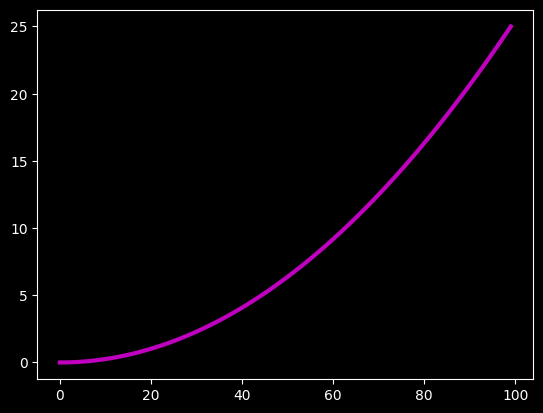

In [ ]:
plt.plot(x, lw = 3, color = 'm')
plt.show()

# Power Transformation ( Square Root )

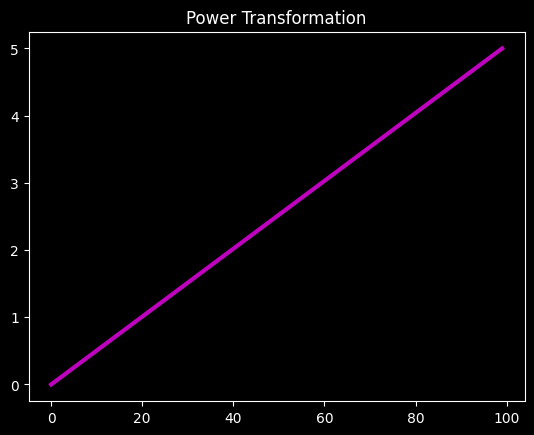

In [ ]:
y = np.sqrt(x) # Square root transformation
plt.plot(y, lw = 3, color = 'm')
plt.title('Power Transformation')
plt.show()

# Create Another data

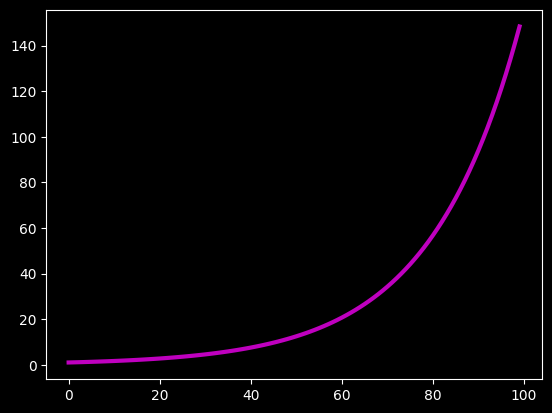

In [ ]:
x1 = np.exp(np.linspace(0, 5, 100))
plt.plot(x1, lw = 3, color = 'm')
plt.show()

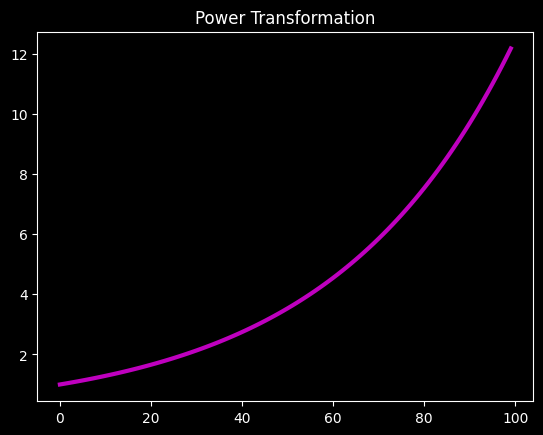

In [ ]:
y1 = np.sqrt(x1) # Square root transformation
plt.plot(y1, lw = 3, color = 'm')
plt.title('Power Transformation')
plt.show()

# Log Transformation

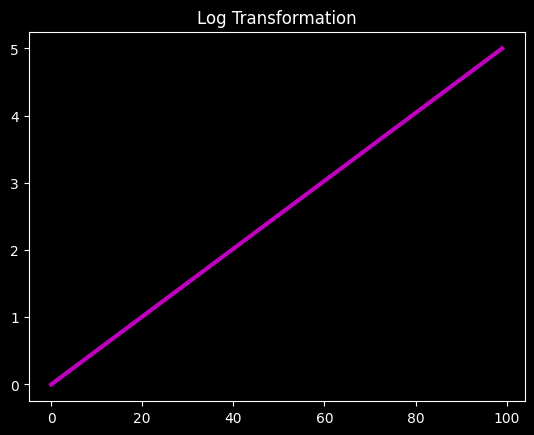

In [ ]:
y_log = np.log(x1)
plt.plot(y_log, lw = 3, color = 'm')
plt.title('Log Transformation')
plt.show()

# Transformations for Regression

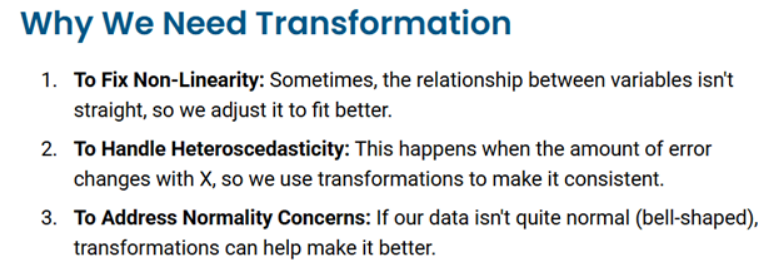

# Generate data to perform Transformations

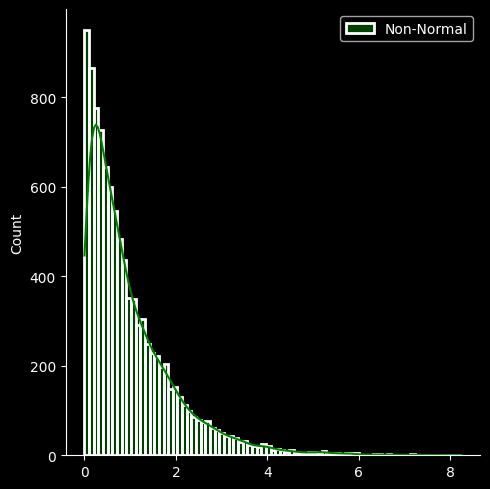

In [ ]:
data = np.random.exponential(size = 10000)

sns.displot(data, kde = True, fill = True, linewidth = 2, label = "Non-Normal", color ="green")
plt.legend()
plt.show()

# Log Transformation of the data

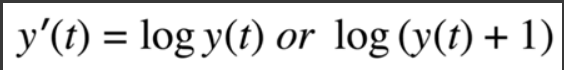

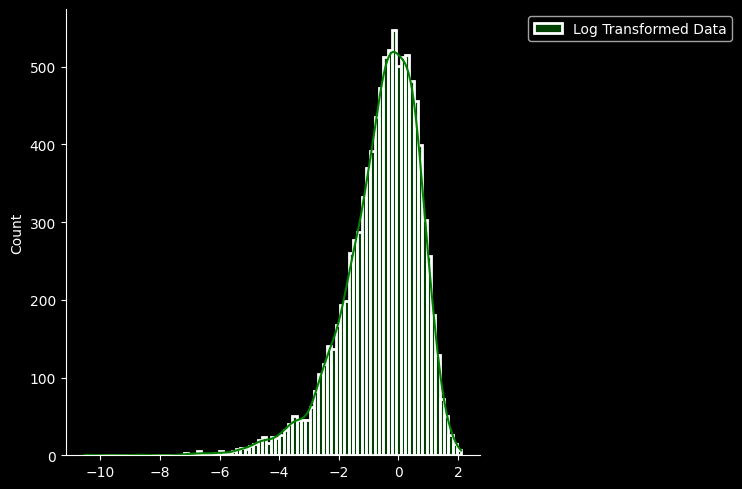

In [ ]:
log_data = np.log(data)
sns.displot(log_data, kde = True, fill = True, linewidth = 2, label = "Log Transformed Data", color ="green")
plt.legend(bbox_to_anchor=(1.1, 1))
plt.show()

### For log transformation data should be positive. log transformation does not make the data normal, it just remove the skewness.

# Power Transformation (Square Root)

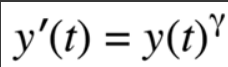

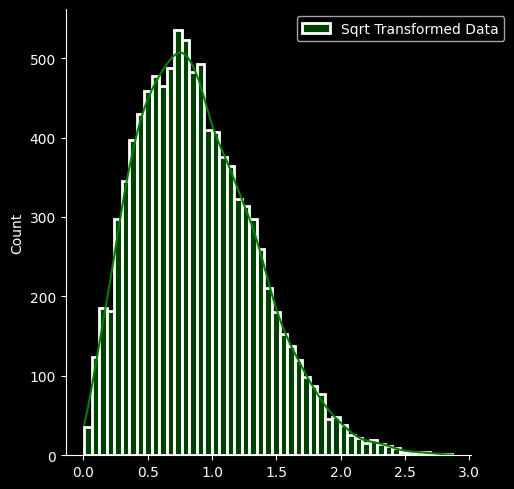

In [ ]:
sqrt_data = np.sqrt(data)
sns.displot(sqrt_data, kde = True, fill = True, linewidth = 2, label = "Sqrt Transformed Data", color ="green")
plt.legend(bbox_to_anchor=(1.1, 1))
plt.show()

# Power Transformation ( Cube Root )

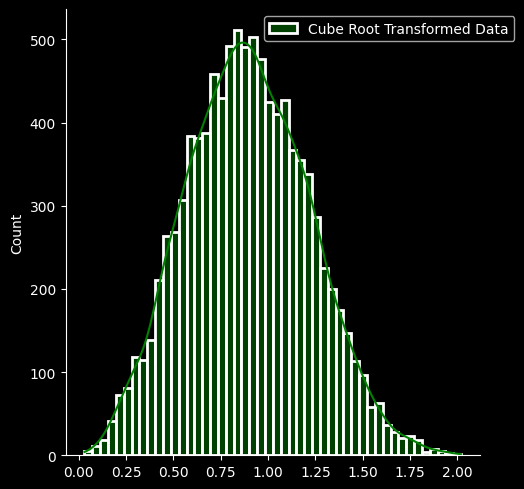

In [ ]:
cbrt_data = np.cbrt(data)
sns.displot(cbrt_data, kde = True, fill = True, linewidth = 2, label = "Cube Root Transformed Data", color ="green")
plt.legend(bbox_to_anchor=(1.1, 1))
plt.show()

# Box-Cox Transformation

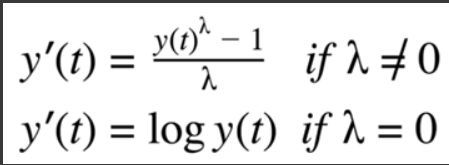

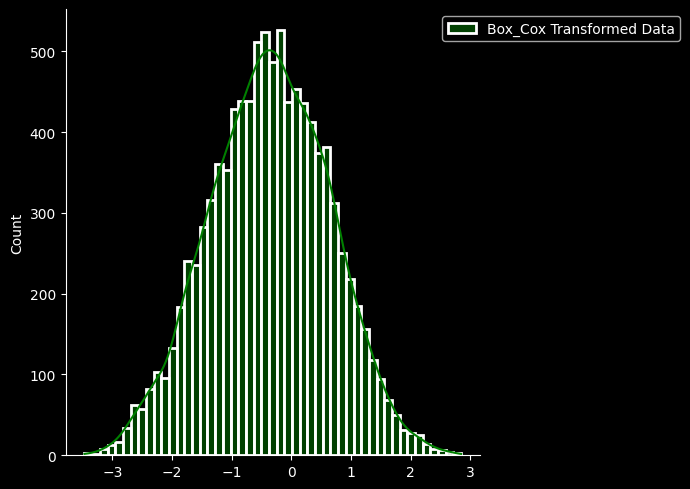

In [ ]:
transformed_data, calculated_lambda = stats.boxcox(data)

sns.displot(transformed_data, kde = True, fill = True, linewidth = 2, label = "Box_Cox Transformed Data", color ="green")
plt.legend(bbox_to_anchor=(1.5, 1))
plt.show()

In [ ]:
calculated_lambda

np.float64(0.2720833546433918)

# Transformations In Regression

## Generate challenging data for Regression Analysis

In [ ]:
X,y = datasets.make_regression(n_samples = 1000, n_features = 1, n_informative = 1,random_state = 42)
X = np.interp(X, (X.min(), X.max()), (0.00005, 2000))
y = np.random.exponential(np.interp(y, (y.min(), y.max()), (2000, 2000000))).reshape(-1,1)
df = pd.DataFrame(data = X, columns = ['Independent'], index = None)
df['Dependent'] = y
df

,Independent,Dependent
0,575.407780,1.085480e+06
1,1174.921243,1.282500e+05
2,1523.688468,5.471412e+06
3,730.100798,1.423068e+06
4,612.118143,6.222760e+05
...,...,...
995,969.210366,4.742920e+06
996,1106.067391,1.097391e+06
997,949.921738,3.783957e+05
998,688.742773,1.109328e+05


## Scatter plot of Independent and Dependent Variables

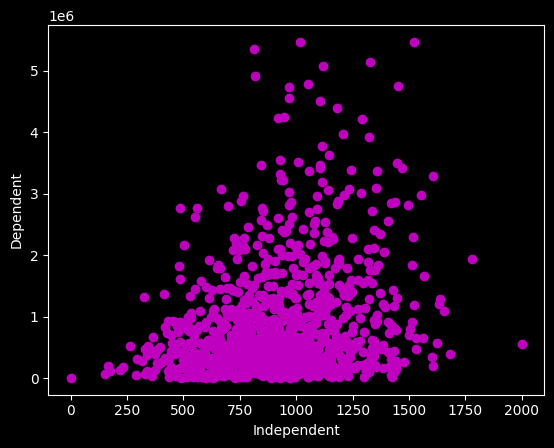

In [ ]:
plt.plot(df['Independent'],df['Dependent'],'mo')
plt.ylabel('Dependent')
plt.xlabel("Independent")
plt.show()

## Extracted X and y from the data

In [ ]:
X = df['Independent'].values
X = sm.add_constant(X)

In [ ]:
y = df['Dependent'].values

## Performing Least Square Regression

In [ ]:
model = sm.OLS(y, X).fit() # Fit the OLS regression model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     61.86
Date:                Thu, 01 May 2025   Prob (F-statistic):           9.53e-15
Time:                        00:00:47   Log-Likelihood:                -15130.
No. Observations:                1000   AIC:                         3.026e+04
Df Residuals:                     998   BIC:                         3.027e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.307e+05   9.92e+04      1.318      0.1

## Plot the Regression Line

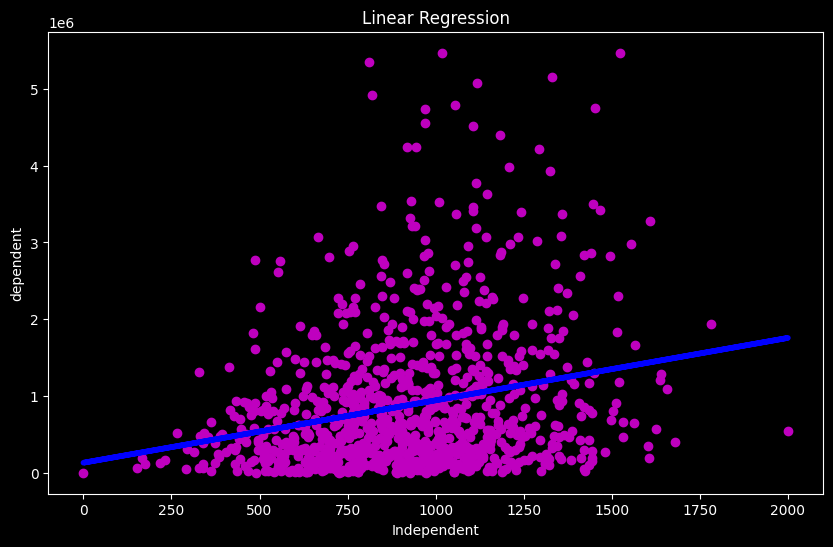

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df['Independent'], df['Dependent'], 'mo')
plt.plot(df['Independent'], model.predict(X), color='b', linewidth=4)
plt.xlabel('Independent')
plt.ylabel('dependent')
plt.title('Linear Regression')
plt.show()

## Get residual and fitted values and plot residual analysis

In [ ]:
# Get residuals and fitted values
residuals = model.resid
fitted_values = model.fittedvalues

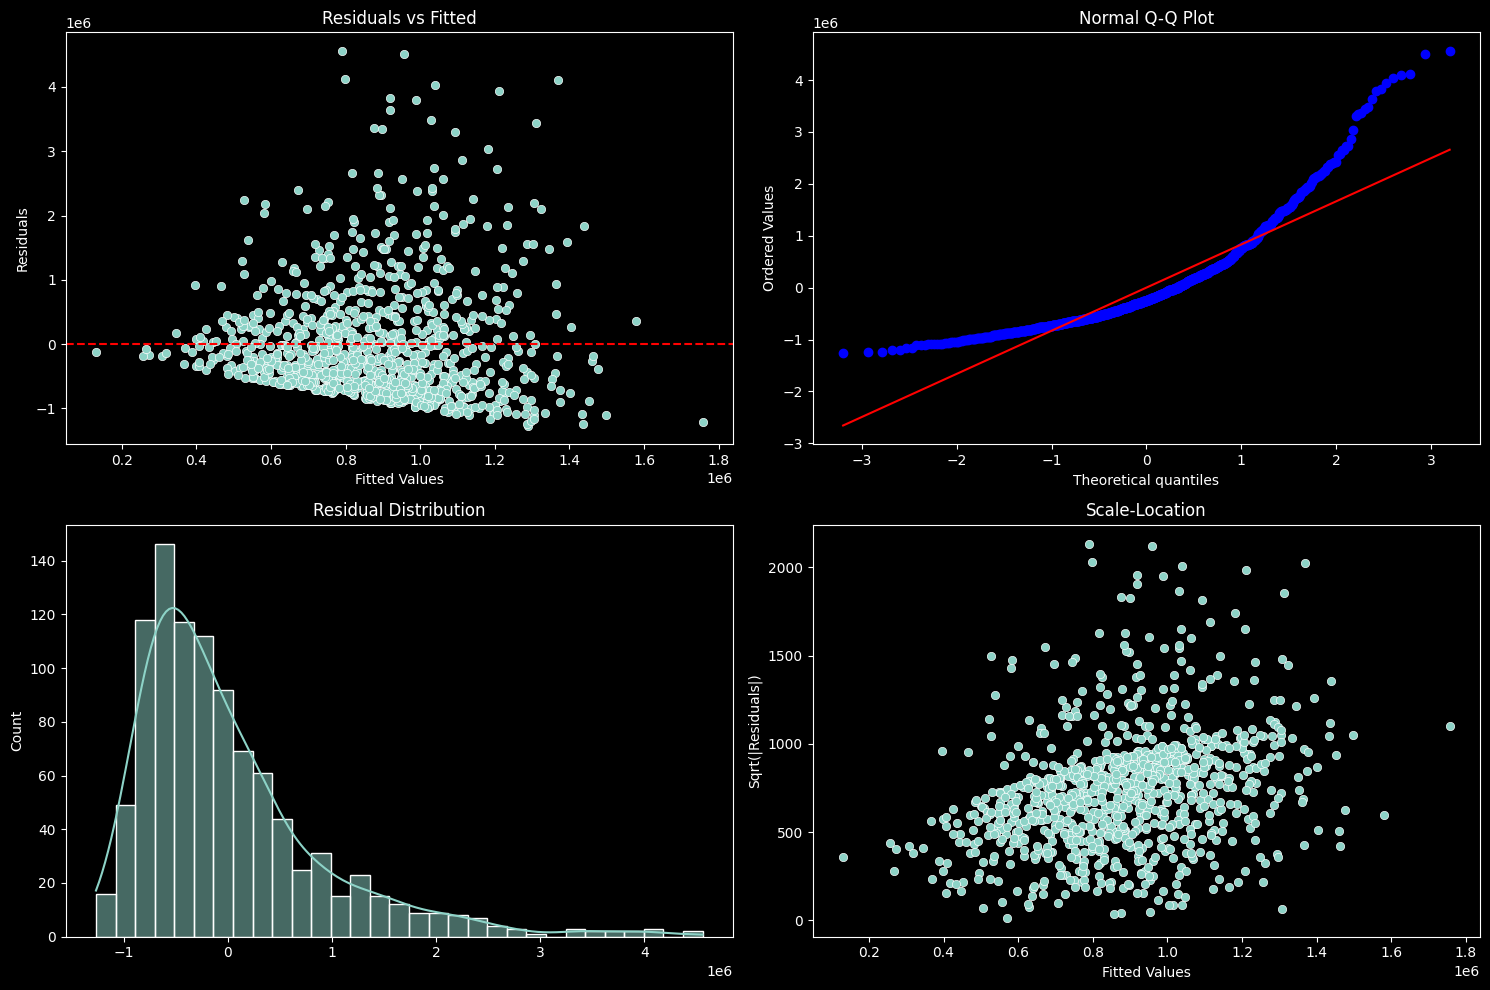

In [ ]:
# Create subplots for residual analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Residuals vs Fitted Values
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0,0])
axes[0,0].axhline(y=0, color='r', linestyle='--')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted')

# 2. QQ Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[0,1])
axes[0,1].set_title('Normal Q-Q Plot')

# 3. Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1,0])
axes[1,0].set_title('Residual Distribution')

# 4. Scale-Location Plot
sns.scatterplot(x=fitted_values, y=np.sqrt(np.abs(residuals)), ax=axes[1,1])
axes[1,1].set_xlabel('Fitted Values')
axes[1,1].set_ylabel('Sqrt(|Residuals|)')
axes[1,1].set_title('Scale-Location')

# Adjust layout and display
plt.tight_layout()
plt.show()

# Perform Log Regression

In [ ]:
df['log_Dependent'] = np.log(df['Dependent'])

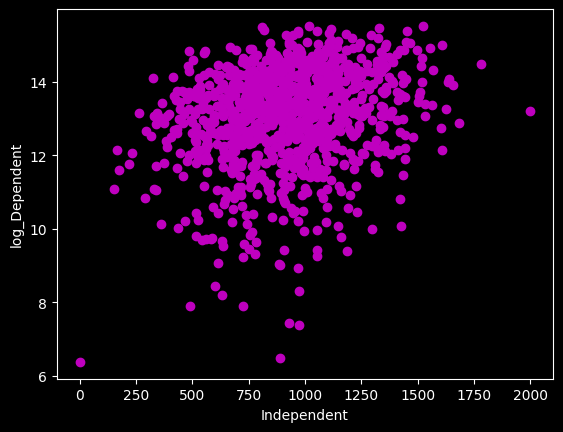

In [ ]:
plt.plot(df['Independent'],df['log_Dependent'],'mo')
plt.ylabel('log_Dependent')
plt.xlabel("Independent")
plt.show()

In [ ]:
y = df['log_Dependent'].values

In [ ]:
log_model = sm.OLS(y, X).fit() # Fit the OLS regression model
print(log_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     56.26
Date:                Thu, 01 May 2025   Prob (F-statistic):           1.40e-13
Time:                        00:00:48   Log-Likelihood:                -1708.3
No. Observations:                1000   AIC:                             3421.
Df Residuals:                     998   BIC:                             3430.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.9762      0.147     81.442      0.0

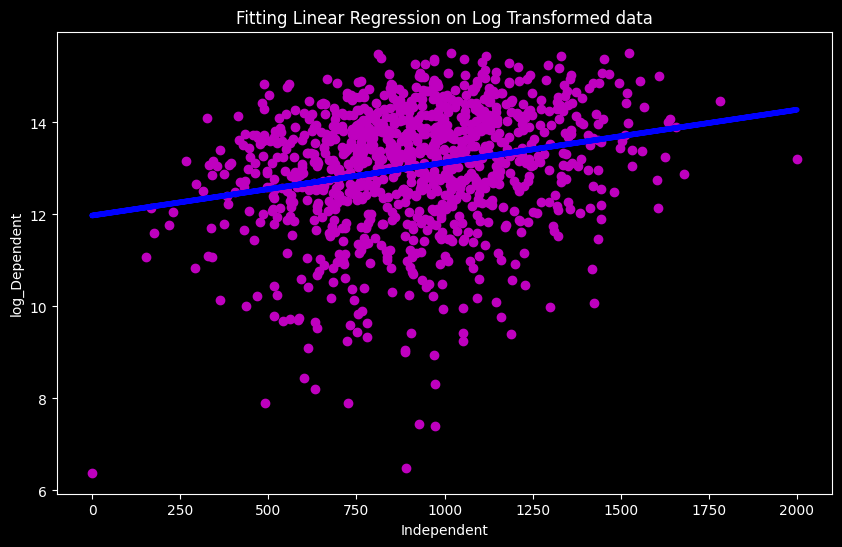

In [ ]:
# Plot the regression line
plt.figure(figsize=(10, 6))
plt.plot(df['Independent'], df['log_Dependent'], 'mo')
plt.plot(df['Independent'], log_model.predict(X), color='b', linewidth=4)
plt.xlabel('Independent')
plt.ylabel('log_Dependent')
plt.title('Fitting Linear Regression on Log Transformed data')
plt.show()

In [ ]:
# Get residuals and fitted values
residuals = log_model.resid
fitted_values = log_model.fittedvalues

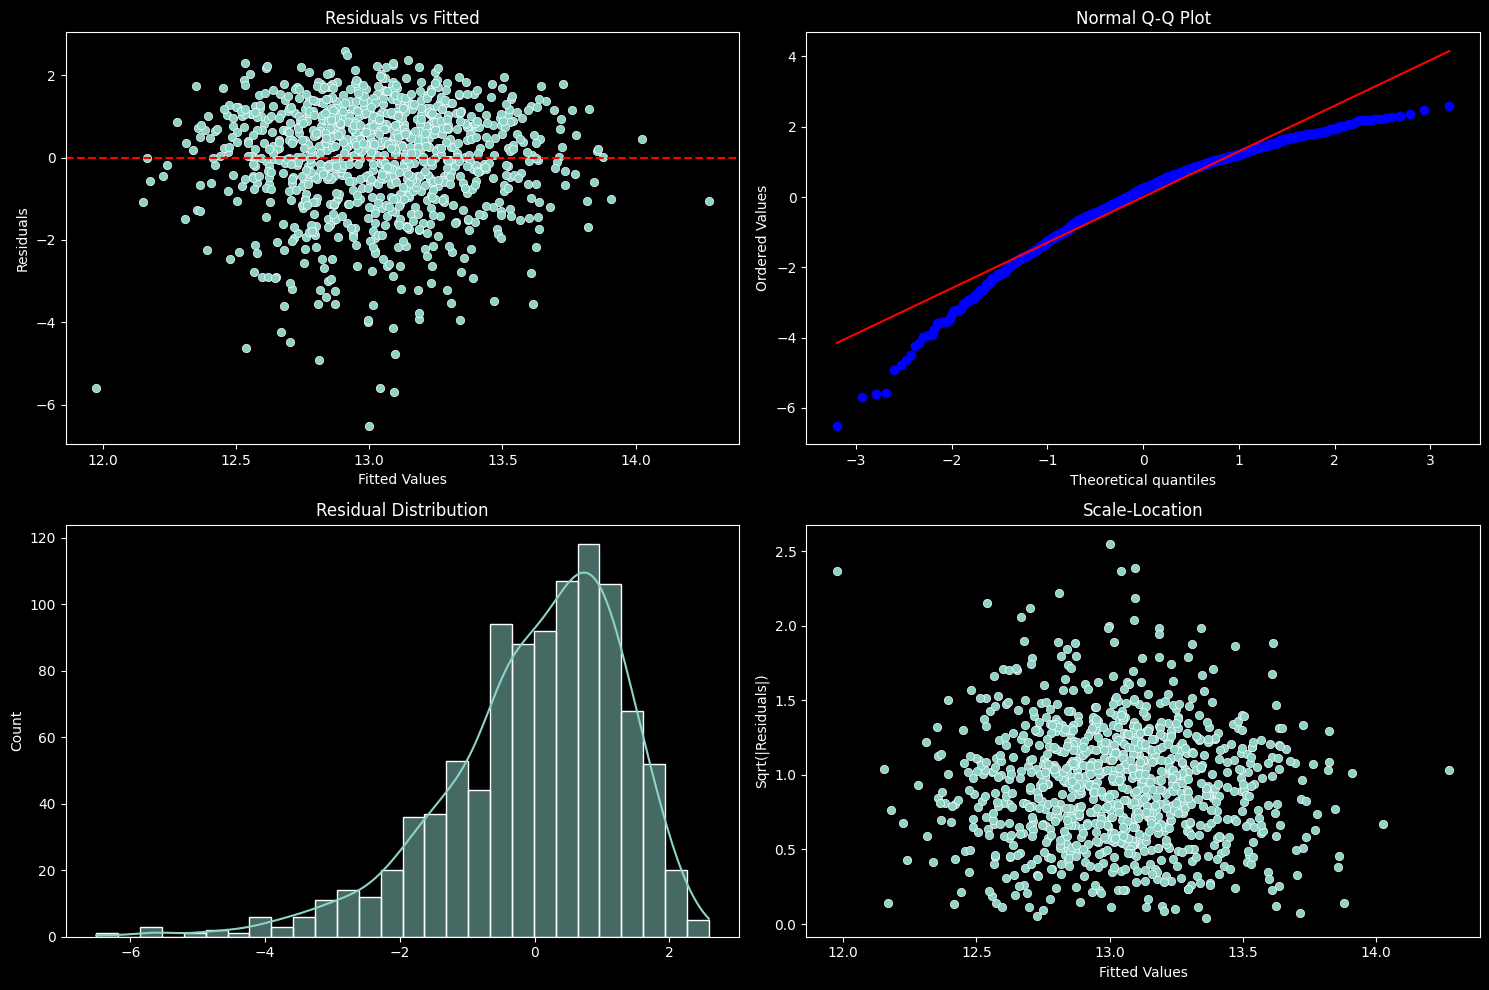

In [ ]:
# Create subplots for residual analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Residuals vs Fitted Values
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0,0])
axes[0,0].axhline(y=0, color='r', linestyle='--')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted')

# 2. QQ Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[0,1])
axes[0,1].set_title('Normal Q-Q Plot')

# 3. Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1,0])
axes[1,0].set_title('Residual Distribution')

# 4. Scale-Location Plot
sns.scatterplot(x=fitted_values, y=np.sqrt(np.abs(residuals)), ax=axes[1,1])
axes[1,1].set_xlabel('Fitted Values')
axes[1,1].set_ylabel('Sqrt(|Residuals|)')
axes[1,1].set_title('Scale-Location')

# Adjust layout and display
plt.tight_layout()
plt.show()

# Box-Cox Regression

In [ ]:
df['boxcox_Dependent'] = np.log(df['Dependent'])

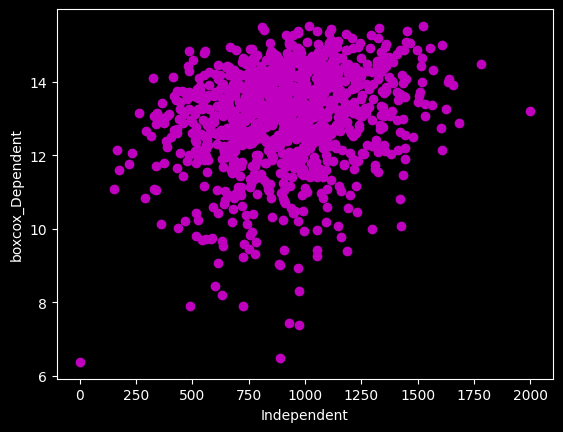

In [ ]:
plt.plot(df['Independent'],df['boxcox_Dependent'],'mo')
plt.ylabel('boxcox_Dependent')
plt.xlabel("Independent")
plt.show()

In [ ]:
y = df['boxcox_Dependent'].values

In [ ]:
boxcox_model = sm.OLS(y, X).fit() # Fit the OLS regression model
print(log_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     56.26
Date:                Thu, 01 May 2025   Prob (F-statistic):           1.40e-13
Time:                        00:00:49   Log-Likelihood:                -1708.3
No. Observations:                1000   AIC:                             3421.
Df Residuals:                     998   BIC:                             3430.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.9762      0.147     81.442      0.0

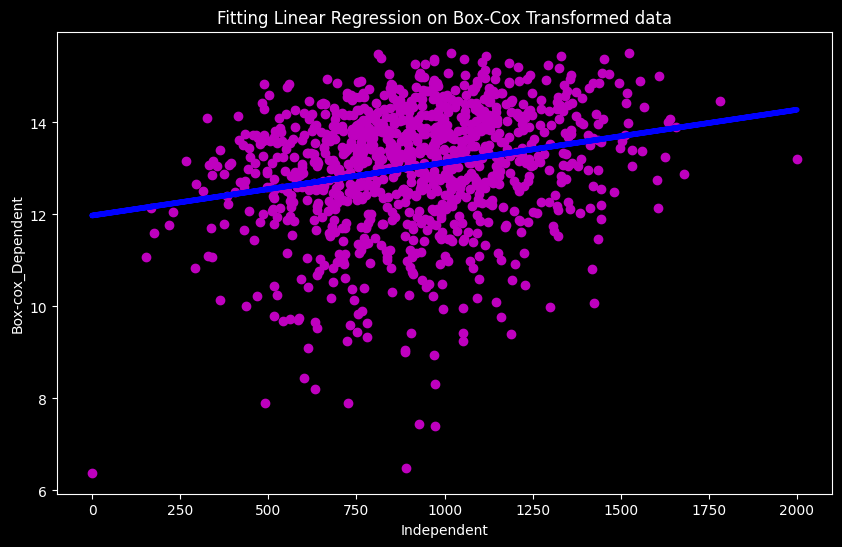

In [ ]:
# Plot the regression line
plt.figure(figsize=(10, 6))
plt.plot(df['Independent'], df['boxcox_Dependent'], 'mo')
plt.plot(df['Independent'], boxcox_model.predict(X), color='b', linewidth=4)
plt.xlabel('Independent')
plt.ylabel('Box-cox_Dependent')
plt.title('Fitting Linear Regression on Box-Cox Transformed data')
plt.show()

In [ ]:
# Get residuals and fitted values
residuals = boxcox_model.resid
fitted_values = boxcox_model.fittedvalues

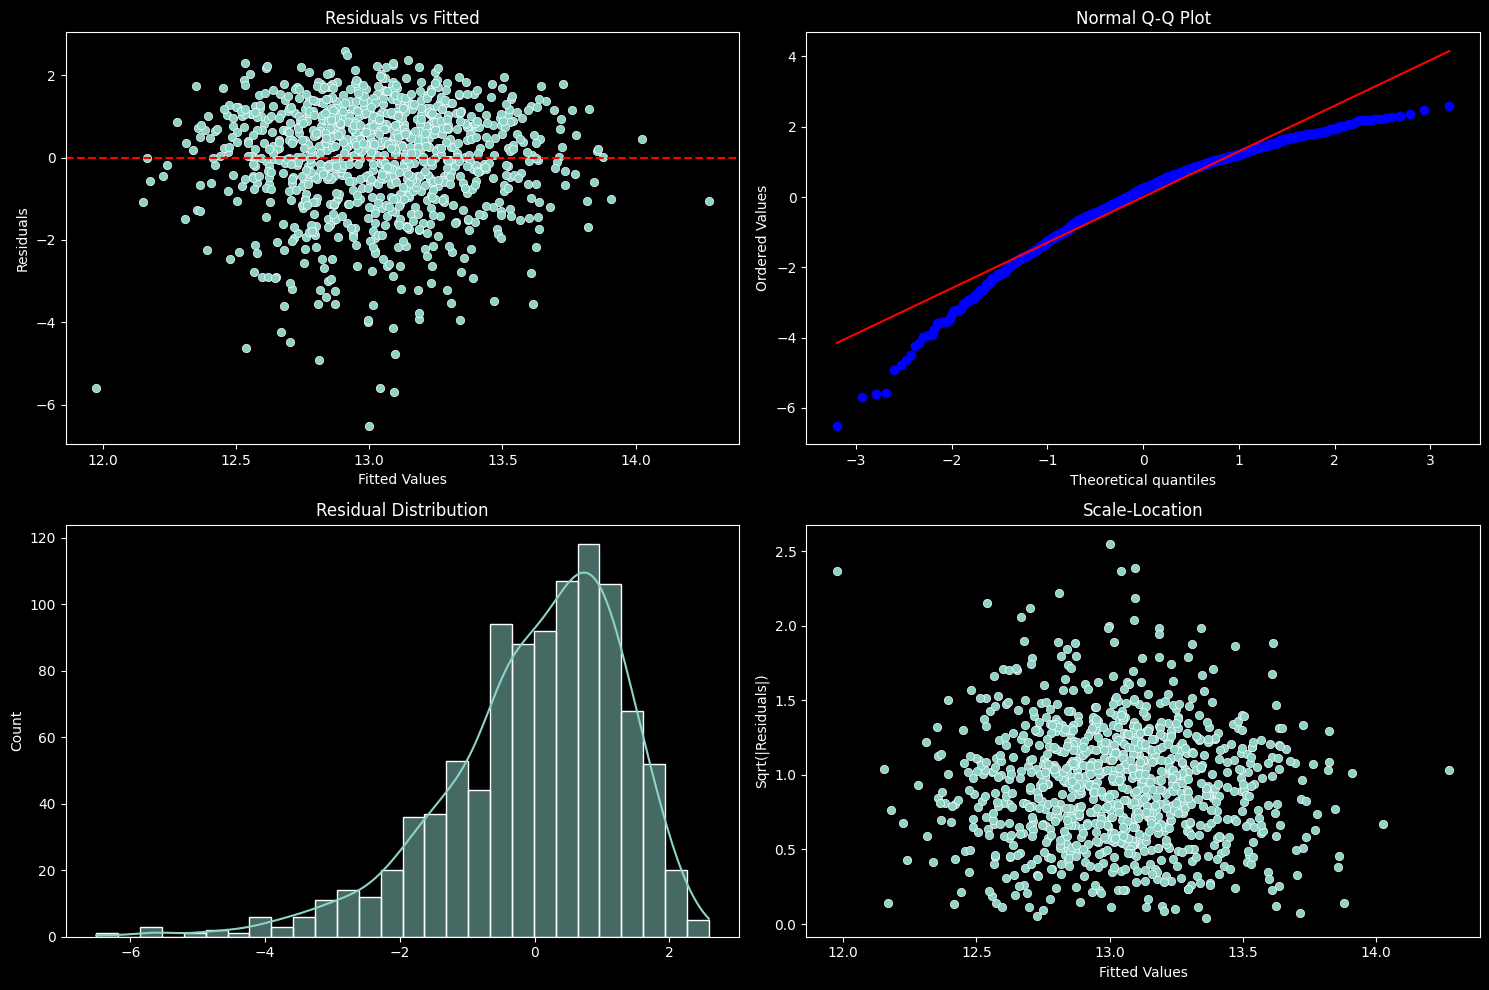

In [ ]:
# Create subplots for residual analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Residuals vs Fitted Values
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0,0])
axes[0,0].axhline(y=0, color='r', linestyle='--')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted')

# 2. QQ Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[0,1])
axes[0,1].set_title('Normal Q-Q Plot')

# 3. Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1,0])
axes[1,0].set_title('Residual Distribution')

# 4. Scale-Location Plot
sns.scatterplot(x=fitted_values, y=np.sqrt(np.abs(residuals)), ax=axes[1,1])
axes[1,1].set_xlabel('Fitted Values')
axes[1,1].set_ylabel('Sqrt(|Residuals|)')
axes[1,1].set_title('Scale-Location')

# Adjust layout and display
plt.tight_layout()
plt.show()